# LoRA Retraining v2: SMS Spam Classifier

This notebook prepares a stronger LoRA adapter for the SMS spam classifier without modifying the existing adapter. It is designed for Google Colab with GPU and saves a new adapter to `smollm2_spam_lora_adapter_v2/`.

The current v2 adapter is integrated successfully, but on the official 75-sample benchmark it reached only `0.1000` spam recall. This notebook addresses the likely causes: weak evaluation, class imbalance, prompt/inference mismatch, prompt-token loss, and limited training signal.

## 0. Colab and Safety Notes

Run this notebook in Google Colab with a GPU runtime. It does not call OpenAI, Pinecone, or any external API-backed classifier. It does not load `.env` and does not use API keys.

The old adapter folder `smollm2_spam_lora_adapter/` is used only in the optional comparison section. The new adapter is saved separately as `smollm2_spam_lora_adapter_v2/`.

In [34]:
# Optional Colab setup. Set USE_GOOGLE_DRIVE = False for local runs.
USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('Google Drive mount skipped.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Project Paths and Configuration

Edit `PROJECT_ROOT` in one place. For Colab, point it at the repository folder in Drive. For local use, set it to the repository root or leave `Path.cwd()` if the notebook is launched from the repo.

In [35]:
from pathlib import Path
import json
import math
import os
import random
import re
from collections import Counter

# EDIT THIS for your Colab Drive layout.
if USE_GOOGLE_DRIVE:
    PROJECT_ROOT = Path('/content/drive/MyDrive/sms-spam-llm-system')
else:
    PROJECT_ROOT = Path.cwd()

DATA_PATH = PROJECT_ROOT / 'data' / 'SMSSpamCollection'
OLD_ADAPTER_DIR = PROJECT_ROOT / 'smollm2_spam_lora_adapter'
NEW_ADAPTER_DIR = PROJECT_ROOT / 'smollm2_spam_lora_adapter_v2'
EVAL_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'lora_v2_eval'

BASE_MODEL_NAME = 'HuggingFaceTB/SmolLM2-1.7B-Instruct'
SEED = 42
MAX_LENGTH = 384

# Training-only oversampling target. Set to None to disable.
TARGET_TRAIN_SPAM_FRACTION = 0.40

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_PATH exists:', DATA_PATH.exists())
print('New adapter path:', NEW_ADAPTER_DIR)
print('Eval output path:', EVAL_OUTPUT_DIR)

PROJECT_ROOT: /content/drive/MyDrive/sms-spam-llm-system
DATA_PATH exists: False
New adapter path: /content/drive/MyDrive/sms-spam-llm-system/smollm2_spam_lora_adapter_v2
Eval output path: /content/drive/MyDrive/sms-spam-llm-system/outputs/lora_v2_eval


## 2. Install and Import Dependencies

Colab may need the install cell below. If your environment already has these packages, you can skip it. The notebook uses local Hugging Face training only; no API credentials are required.

In [36]:
# Uncomment in Colab if needed.
# %pip install -q transformers datasets peft accelerate scikit-learn matplotlib pandas

In [37]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from peft import LoraConfig, PeftModel, TaskType, get_peft_model
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from transformers import AutoModelForCausalLM, AutoTokenizer, DataCollatorForSeq2Seq, Trainer, TrainingArguments

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
cuda available: True
gpu: NVIDIA A100-SXM4-80GB


## 3. Load Dataset

The dataset is loaded from `data/SMSSpamCollection`. We keep only `text` and `label`, normalize labels, and inspect class balance. The original dataset is ham-heavy, so spam recall needs special attention.

In [38]:
from pathlib import Path
import pandas as pd

DATA_PATH = PROJECT_ROOT / "data" / "SMSSpamCollection"

if DATA_PATH.exists():
    print("Loading local dataset:", DATA_PATH)

    rows = []
    with DATA_PATH.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            label, text = line.split("\t", 1)
            rows.append({"label": label.strip().lower(), "text": text})

    df = pd.DataFrame(rows)

else:
    print("Local data/SMSSpamCollection not found. Downloading from KaggleHub...")

    try:
        import kagglehub
    except ImportError:
        !pip -q install kagglehub
        import kagglehub

    kaggle_path = Path(kagglehub.dataset_download("uciml/sms-spam-collection-dataset"))
    print("Path to dataset files:", kaggle_path)

    csv_candidates = list(kaggle_path.rglob("spam.csv")) + list(kaggle_path.rglob("*.csv"))
    assert csv_candidates, f"No CSV files found under {kaggle_path}"

    csv_path = csv_candidates[0]
    print("Loading Kaggle CSV:", csv_path)

    raw = pd.read_csv(csv_path, encoding="latin-1")

    if {"v1", "v2"}.issubset(raw.columns):
        df = raw[["v1", "v2"]].rename(columns={"v1": "label", "v2": "text"})
    elif {"label", "text"}.issubset(raw.columns):
        df = raw[["label", "text"]].copy()
    else:
        raise ValueError(f"Unexpected columns: {raw.columns.tolist()}")

    df["label"] = df["label"].astype(str).str.strip().str.lower()
    df["text"] = df["text"].astype(str)

assert set(df["label"].unique()) == {"ham", "spam"}

print("shape:", df.shape)
display(df.head())
print("Label distribution:")
display(df["label"].value_counts().rename_axis("label").reset_index(name="count"))
print("Spam fraction:", round((df["label"] == "spam").mean(), 4))

Local data/SMSSpamCollection not found. Downloading from KaggleHub...
Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset
Loading Kaggle CSV: /kaggle/input/sms-spam-collection-dataset/spam.csv
shape: (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Label distribution:


,label,count
0,ham,4825
1,spam,747


Spam fraction: 0.1341


## 4. Stratified Train/Validation/Test Split

The old notebook evaluated on only 15 examples, with only 2 spam examples. This version uses stratified 80/10/10 splits, giving validation and test sets enough spam examples for meaningful spam recall.

In [39]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df['label'],
    random_state=SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

for name, split in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    counts = split['label'].value_counts().to_dict()
    print(f'{name}: rows={len(split)}, counts={counts}, spam_fraction={(split["label"] == "spam").mean():.4f}')

train: rows=4457, counts={'ham': 3859, 'spam': 598}, spam_fraction=0.1342
validation: rows=557, counts={'ham': 483, 'spam': 74}, spam_fraction=0.1329
test: rows=558, counts={'ham': 483, 'spam': 75}, spam_fraction=0.1344


## 5. Optional Spam Oversampling for Training Only

We oversample spam only in the training split. Validation and test remain natural-distribution splits. This directly targets the ham bias observed in the current adapter while preserving honest evaluation.

In [40]:
def oversample_spam(train: pd.DataFrame, target_spam_fraction: float | None, seed: int = 42) -> pd.DataFrame:
    if target_spam_fraction is None:
        return train.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    if not 0 < target_spam_fraction < 1:
        raise ValueError('target_spam_fraction must be between 0 and 1, or None')

    spam_df = train[train['label'] == 'spam']
    ham_df = train[train['label'] == 'ham']
    n_ham = len(ham_df)
    target_spam_n = math.ceil((target_spam_fraction * n_ham) / (1 - target_spam_fraction))
    if target_spam_n <= len(spam_df):
        balanced = pd.concat([
            ham_df,
            spam_df.sample(n=target_spam_n, random_state=seed, replace=False),
        ])
    else:
        balanced = pd.concat([
            ham_df,
            spam_df.sample(n=target_spam_n, random_state=seed, replace=True),
        ])
    return balanced.sample(frac=1.0, random_state=seed).reset_index(drop=True)

train_balanced_df = oversample_spam(train_df, TARGET_TRAIN_SPAM_FRACTION, SEED)

print('Before oversampling:')
display(train_df['label'].value_counts().rename_axis('label').reset_index(name='count'))
print('fraction:', round((train_df['label'] == 'spam').mean(), 4))

print('After oversampling:')
display(train_balanced_df['label'].value_counts().rename_axis('label').reset_index(name='count'))
print('fraction:', round((train_balanced_df['label'] == 'spam').mean(), 4))

Before oversampling:


,label,count
0,ham,3859
1,spam,598


fraction: 0.1342
After oversampling:


,label,count
0,ham,3859
1,spam,2573


fraction: 0.4


## 6. Prompt Format Matching Inference

The current production inference uses `tokenizer.apply_chat_template`. The old notebook trained on raw `question + answer` text, creating a format mismatch. This v2 notebook trains with chat-template text.

We train SMS-only prompts first. Evidence-aware prompting is intentionally excluded from this first v2 adapter because evidence generation can introduce noise and label leakage.

In [41]:
SYSTEM_PROMPT = 'Classify the SMS as spam or ham. Answer with exactly one word: spam or ham.'


def build_messages(text: str, label: str | None = None):
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': f'SMS: {text}'},
    ]
    if label is not None:
        messages.append({'role': 'assistant', 'content': label})
    return messages

print(build_messages('Congratulations! You won a prize. Call now!', 'spam'))

[{'role': 'system', 'content': 'Classify the SMS as spam or ham. Answer with exactly one word: spam or ham.'}, {'role': 'user', 'content': 'SMS: Congratulations! You won a prize. Call now!'}, {'role': 'assistant', 'content': 'spam'}]


## 7. Load Tokenizer and Model

Use the same base model as the current adapter. The tokenizer is loaded from the base model rather than the old adapter, avoiding the stale `TokenizerBackend` metadata issue in the old adapter folder.

In [42]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
)
model.to(device)

print('Loaded base model on:', device)
print('pad_token:', tokenizer.pad_token, tokenizer.pad_token_id)
print('eos_token:', tokenizer.eos_token, tokenizer.eos_token_id)

Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

Loaded base model on: cuda
pad_token: <|im_end|> 2
eos_token: <|im_end|> 2


## 8. Supervised Causal LM Tokenization with Prompt Masking

The old notebook copied all `input_ids` into `labels`, so the loss included prompt tokens. Here, prompt tokens are masked with `-100`, and only the assistant answer tokens contribute to loss. This focuses learning on emitting `spam` or `ham`.

In [43]:
def chat_text(text: str, label: str | None = None) -> str:
    return tokenizer.apply_chat_template(
        build_messages(text, label),
        tokenize=False,
        add_generation_prompt=(label is None),
    )


def tokenize_supervised(example):
    full_text = chat_text(example['text'], example['label'])
    prompt_text = chat_text(example['text'], None)

    full = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )
    prompt = tokenizer(
        prompt_text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

    input_ids = full['input_ids']
    labels = input_ids.copy()
    prompt_len = min(len(prompt['input_ids']), len(labels))
    labels[:prompt_len] = [-100] * prompt_len

    return {
        'input_ids': input_ids,
        'attention_mask': full['attention_mask'],
        'labels': labels,
    }


def make_dataset(split_df: pd.DataFrame) -> Dataset:
    return Dataset.from_pandas(split_df[['text', 'label']].reset_index(drop=True)).map(
        tokenize_supervised,
        remove_columns=['text', 'label'],
    )

train_dataset = make_dataset(train_balanced_df)
val_dataset = make_dataset(val_df)
test_dataset = make_dataset(test_df)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Map:   0%|          | 0/6432 [00:00<?, ? examples/s]

Map:   0%|          | 0/557 [00:00<?, ? examples/s]

Map:   0%|          | 0/558 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 6432
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 557
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 558
})


## 9. Masking Sanity Check

This verifies that the unmasked labels decode to the target label rather than the full prompt. If this check does not decode to `spam` or `ham`, stop and inspect the chat template before training.

In [44]:
sample_row = train_balanced_df.iloc[0].to_dict()
encoded = tokenize_supervised(sample_row)
input_ids = encoded['input_ids']
labels = encoded['labels']

unmasked_ids = [tok for tok, lab in zip(input_ids, labels) if lab != -100]
masked_count = sum(1 for lab in labels if lab == -100)

print('Gold label:', sample_row['label'])
print('Full decoded training text:')
print(tokenizer.decode(input_ids, skip_special_tokens=False))
print('Masked prompt token count:', masked_count)
print('Unmasked label token count:', len(unmasked_ids))
print('Decoded unmasked label tokens:')
print(repr(tokenizer.decode(unmasked_ids, skip_special_tokens=True).strip()))

Gold label: spam
Full decoded training text:
<|im_start|>system
Classify the SMS as spam or ham. Answer with exactly one word: spam or ham.<|im_end|>
<|im_start|>user
SMS: Sunshine Quiz Wkly Q! Win a top Sony DVD player if u know which country Liverpool played in mid week? Txt ansr to 82277. å£1.50 SP:Tyrone<|im_end|>
<|im_start|>assistant
spam<|im_end|>

Masked prompt token count: 84
Unmasked label token count: 4
Decoded unmasked label tokens:
'spam'


## 10. LoRA Configuration

The old adapter used `r=8`, `alpha=16`, and only `q_proj`/`v_proj`. This version starts with a slightly stronger configuration and broader target modules. If Colab memory is tight, switch `TARGET_MODULES` back to `['q_proj', 'v_proj']`.

In [45]:
!pip -q install -U "torchao>=0.16.0" peft transformers accelerate datasets evaluate sentencepiece scikit-learn pandas matplotlib kagglehub

In [46]:
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
# Fallback for memory-constrained runs:
# TARGET_MODULES = ['q_proj', 'v_proj']

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    target_modules=TARGET_MODULES,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 18,087,936 || all params: 1,729,464,320 || trainable%: 1.0459


## 11. Training Arguments

These defaults are Colab-friendly starting points. `metric_for_best_model='eval_spam_recall'` prioritizes the weakness we are trying to fix. If your `transformers` version uses `evaluation_strategy` instead of `eval_strategy`, the helper below selects the supported name automatically.

In [47]:
import inspect
import torch
from transformers import TrainingArguments

TRAIN_EPOCHS = 3
PER_DEVICE_BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 8
LEARNING_RATE = 1e-4

args_kwargs = dict(
    output_dir=str(PROJECT_ROOT / "outputs" / "lora_v2_checkpoints"),
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    num_train_epochs=TRAIN_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=0.03,
    logging_steps=25,

    # Save checkpoints, but do NOT evaluate during training.
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=False,

    report_to="none",
    fp16=torch.cuda.is_available(),
    prediction_loss_only=True,
)

sig = inspect.signature(TrainingArguments.__init__)

# Turn off training-time evaluation to avoid CausalLM logits OOM on T4.
if "eval_strategy" in sig.parameters:
    args_kwargs["eval_strategy"] = "no"
elif "evaluation_strategy" in sig.parameters:
    args_kwargs["evaluation_strategy"] = "no"
else:
    print("Warning: TrainingArguments does not expose eval_strategy/evaluation_strategy.")

training_args = TrainingArguments(**args_kwargs)

print("eval strategy:", getattr(training_args, "eval_strategy", None))
print("evaluation strategy:", getattr(training_args, "evaluation_strategy", None))
print(training_args)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


eval strategy: IntervalStrategy.NO
evaluation strategy: None
TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=False,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eva

## 12. Metrics for Validation During Training

The trainer evaluates token-level generation indirectly through labels. For final model quality, use the generation-based evaluation section below. These metrics still help select checkpoints, especially spam recall.

In [48]:
LABEL_ORDER = ["ham", "spam"]


def normalize_label(text: str) -> str:
    """Normalize model text output into spam / ham / unknown."""
    if text is None:
        return "unknown"

    s = str(text).strip().lower()

    # Remove common chat/template wrappers that may appear in generation.
    s = s.replace("<|im_start|>", " ")
    s = s.replace("<|im_end|>", " ")
    s = s.replace("assistant", " ")

    # Collapse whitespace.
    s = re.sub(r"\s+", " ", s).strip()

    # Exact match first.
    if s in {"spam", "ham"}:
        return s

    # Find the last standalone spam/ham token.
    matches = re.findall(r"\b(spam|ham)\b", s)
    return matches[-1] if matches else "unknown"


# Sanity checks: these should all parse correctly.
for example in [
    "spam",
    "ham",
    "assistant\nspam",
    "assistant\nham",
    "The answer is spam.",
    "<|im_start|>assistant\nspam<|im_end|>",
]:
    print(repr(example), "->", normalize_label(example))

'spam' -> spam
'ham' -> ham
'assistant\nspam' -> spam
'assistant\nham' -> ham
'The answer is spam.' -> spam
'<|im_start|>assistant\nspam<|im_end|>' -> spam


## 13. Train

This is the first GPU-heavy cell. Do not run it locally unless your machine can handle SmolLM2-1.7B LoRA training.

In [49]:
from transformers import DataCollatorForSeq2Seq, Trainer

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator,
)

train_result = trainer.train()
print(train_result)

Step,Training Loss
25,0.170220
50,0.050404
75,0.029189
100,0.031373
125,0.016421
150,0.008417
175,0.010391
200,0.013929
225,0.021983
250,0.010150


TrainOutput(global_step=1206, training_loss=0.008922667224128244, metrics={'train_runtime': 2115.5508, 'train_samples_per_second': 9.121, 'train_steps_per_second': 0.57, 'total_flos': 1.6978569752543232e+16, 'train_loss': 0.008922667224128244, 'epoch': 3.0})


## 14. Generation-Based Evaluation Utilities

Final evaluation uses deterministic generation, parses `spam`/`ham` robustly, and reports confusion-matrix metrics. This matches how the adapter is used as a classifier.

In [50]:
def generate_label(model_to_eval, text: str, max_new_tokens: int = 8) -> tuple[str, str]:
    model_to_eval.eval()
    prompt = chat_text(text, None)
    enc = tokenizer(prompt, return_tensors='pt').to(model_to_eval.device)
    prompt_len = enc['input_ids'].shape[1]
    with torch.no_grad():
        out = model_to_eval.generate(
            input_ids=enc['input_ids'],
            attention_mask=enc['attention_mask'],
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    decoded_new = tokenizer.decode(out[0][prompt_len:], skip_special_tokens=True)
    label = normalize_label(decoded_new)
    return label, decoded_new


def evaluate_generation(model_to_eval, split_df: pd.DataFrame, split_name: str) -> tuple[dict, pd.DataFrame]:
    rows = []
    for i, row in split_df.reset_index(drop=True).iterrows():
        pred, raw = generate_label(model_to_eval, row['text'])
        rows.append({
            'split': split_name,
            'row_id': i,
            'text': row['text'],
            'true_label': row['label'],
            'predicted_label': pred,
            'raw_output': raw,
        })
    pred_df = pd.DataFrame(rows)
    metrics = classification_metrics(pred_df['true_label'].tolist(), pred_df['predicted_label'].tolist())
    metrics = {k: float(v) if isinstance(v, (np.floating, float)) else int(v) for k, v in metrics.items()}
    return metrics, pred_df

## 15. Evaluate on Validation and Test Splits

Inspect spam misses and false positives explicitly. The goal is not just higher accuracy; the goal is materially better spam recall without exploding ham false positives.

In [52]:
import re
import numpy as np
import pandas as pd

LABEL_ORDER = ["ham", "spam"]


def normalize_label(text: str) -> str:
    """Normalize model text output into spam / ham / unknown."""
    if text is None:
        return "unknown"

    s = str(text).strip().lower()

    # Remove common chat/template wrappers.
    s = s.replace("<|im_start|>", " ")
    s = s.replace("<|im_end|>", " ")
    s = s.replace("assistant", " ")

    # Collapse whitespace.
    s = re.sub(r"\s+", " ", s).strip()

    # Exact match first.
    if s in {"spam", "ham"}:
        return s

    # Last standalone spam/ham token.
    matches = re.findall(r"\b(spam|ham)\b", s)
    return matches[-1] if matches else "unknown"


def classification_metrics(y_true, y_pred):
    """
    Compute binary spam/ham metrics.
    Positive class = spam.
    unknown counts as incorrect.
    """
    y_true = [str(x).lower() for x in y_true]
    y_pred = [str(x).lower() for x in y_pred]

    tp = sum((t == "spam") and (p == "spam") for t, p in zip(y_true, y_pred))
    fp = sum((t == "ham") and (p == "spam") for t, p in zip(y_true, y_pred))
    fn = sum((t == "spam") and (p != "spam") for t, p in zip(y_true, y_pred))
    tn = sum((t == "ham") and (p == "ham") for t, p in zip(y_true, y_pred))

    total = len(y_true)
    accuracy = (tp + tn) / total if total else 0.0

    spam_precision = tp / (tp + fp) if (tp + fp) else 0.0
    spam_recall = tp / (tp + fn) if (tp + fn) else 0.0
    spam_f1 = (
        2 * spam_precision * spam_recall / (spam_precision + spam_recall)
        if (spam_precision + spam_recall)
        else 0.0
    )

    ham_precision = tn / (tn + fn) if (tn + fn) else 0.0
    ham_recall = tn / (tn + fp) if (tn + fp) else 0.0
    ham_f1 = (
        2 * ham_precision * ham_recall / (ham_precision + ham_recall)
        if (ham_precision + ham_recall)
        else 0.0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": (spam_precision + ham_precision) / 2,
        "recall_macro": (spam_recall + ham_recall) / 2,
        "f1_macro": (spam_f1 + ham_f1) / 2,
        "spam_precision": spam_precision,
        "spam_recall": spam_recall,
        "ham_precision": ham_precision,
        "ham_recall": ham_recall,
        "spam_f1": spam_f1,
        "ham_f1": ham_f1,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "unknown_count": sum(p == "unknown" for p in y_pred),
        "n": total,
    }


# Sanity checks
for x in [
    "spam",
    "ham",
    "assistant\nspam",
    "assistant\nham",
    "The answer is spam.",
    "<|im_start|>assistant\nspam<|im_end|>",
]:
    print(repr(x), "->", normalize_label(x))

'spam' -> spam
'ham' -> ham
'assistant\nspam' -> spam
'assistant\nham' -> ham
'The answer is spam.' -> spam
'<|im_start|>assistant\nspam<|im_end|>' -> spam


In [53]:
val_metrics, val_predictions = evaluate_generation(model, val_df, 'validation')
test_metrics, test_predictions = evaluate_generation(model, test_df, 'test')

print('Validation metrics:')
print(json.dumps(val_metrics, indent=2))
print('Test metrics:')
print(json.dumps(test_metrics, indent=2))

all_predictions = pd.concat([val_predictions, test_predictions], ignore_index=True)

def show_errors(pred_df: pd.DataFrame, title: str):
    print(f'{title}')
    false_negatives = pred_df[(pred_df['true_label'] == 'spam') & (pred_df['predicted_label'] != 'spam')]
    false_positives = pred_df[(pred_df['true_label'] == 'ham') & (pred_df['predicted_label'] == 'spam')]
    print('False negatives:', len(false_negatives))
    display(false_negatives[['row_id', 'true_label', 'predicted_label', 'raw_output', 'text']].head(20))
    print('False positives:', len(false_positives))
    display(false_positives[['row_id', 'true_label', 'predicted_label', 'raw_output', 'text']].head(20))

show_errors(val_predictions, 'Validation errors')
show_errors(test_predictions, 'Test errors')

Validation metrics:
{
  "accuracy": 0.9910233393177738,
  "precision_macro": 0.9948770491803278,
  "recall_macro": 0.9662162162162162,
  "f1_macro": 0.9799428172239707,
  "spam_precision": 1.0,
  "spam_recall": 0.9324324324324325,
  "ham_precision": 0.9897540983606558,
  "ham_recall": 1.0,
  "spam_f1": 0.965034965034965,
  "ham_f1": 0.9948506694129764,
  "tp": 69,
  "fp": 0,
  "fn": 5,
  "tn": 483,
  "unknown_count": 0,
  "n": 557
}
Test metrics:
{
  "accuracy": 0.9910394265232975,
  "precision_macro": 0.9845919778699862,
  "recall_macro": 0.9845919778699862,
  "f1_macro": 0.9845919778699862,
  "spam_precision": 0.9733333333333334,
  "spam_recall": 0.9733333333333334,
  "ham_precision": 0.995850622406639,
  "ham_recall": 0.995850622406639,
  "spam_f1": 0.9733333333333334,
  "ham_f1": 0.995850622406639,
  "tp": 73,
  "fp": 2,
  "fn": 2,
  "tn": 480,
  "unknown_count": 1,
  "n": 558
}
Validation errors
False negatives: 5


,row_id,true_label,predicted_label,raw_output,text
24,24,spam,ham,ham,ROMCAPspam Everyone around should be respondin...
321,321,spam,ham,ham,"Latest News! Police station toilet stolen, cop..."
342,342,spam,ham,ham,This msg is for your mobile content order It h...
343,343,spam,ham,ham,Sorry I missed your call let's talk when you h...
385,385,spam,ham,ham,For sale - arsenal dartboard. Good condition b...


False positives: 0


,row_id,true_label,predicted_label,raw_output,text


Test errors
False negatives: 2


,row_id,true_label,predicted_label,raw_output,text
310,310,spam,ham,ham,RCT' THNQ Adrian for U text. Rgds Vatian
472,472,spam,ham,ham,"Do you realize that in about 40 years, we'll h..."


False positives: 2


,row_id,true_label,predicted_label,raw_output,text
236,236,ham,spam,spam,"MOON has come to color your dreams, STARS to m..."
357,357,ham,spam,spam,Somebody set up a website where you can play h...


## 16. Confusion Matrix Plot

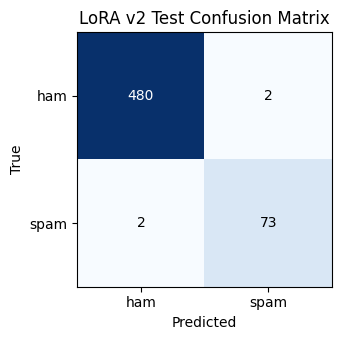

In [54]:
def plot_confusion(pred_df: pd.DataFrame, title: str, out_path: Path | None = None):
    cm = confusion_matrix(pred_df['true_label'], pred_df['predicted_label'], labels=LABEL_ORDER)
    fig, ax = plt.subplots(figsize=(4, 3.5))
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(LABEL_ORDER)))
    ax.set_xticklabels(LABEL_ORDER)
    ax.set_yticks(range(len(LABEL_ORDER)))
    ax.set_yticklabels(LABEL_ORDER)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    max_val = cm.max() or 1
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            ax.text(c, r, int(cm[r, c]), ha='center', va='center', color='white' if cm[r, c] > max_val / 2 else 'black')
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=140)
    plt.show()

plot_confusion(test_predictions, 'LoRA v2 Test Confusion Matrix')

## 17. Save Adapter and Evaluation Artifacts

This saves the new adapter to `smollm2_spam_lora_adapter_v2/` and writes evaluation artifacts to `outputs/lora_v2_eval/`. It does not overwrite the old adapter.

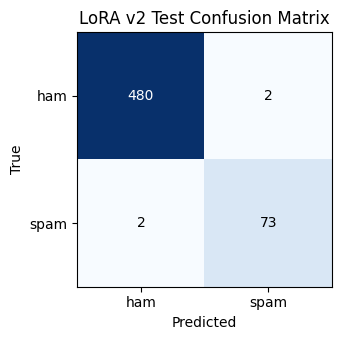

Saved adapter to: /content/drive/MyDrive/sms-spam-llm-system/smollm2_spam_lora_adapter_v2
Saved evaluation artifacts to: /content/drive/MyDrive/sms-spam-llm-system/outputs/lora_v2_eval


In [55]:
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NEW_ADAPTER_DIR.mkdir(parents=True, exist_ok=True)

trainer.model.save_pretrained(NEW_ADAPTER_DIR)
tokenizer.save_pretrained(NEW_ADAPTER_DIR)

metrics_payload = {
    'base_model': BASE_MODEL_NAME,
    'new_adapter_dir': str(NEW_ADAPTER_DIR.relative_to(PROJECT_ROOT)),
    'seed': SEED,
    'max_length': MAX_LENGTH,
    'target_train_spam_fraction': TARGET_TRAIN_SPAM_FRACTION,
    'train_rows_original': len(train_df),
    'train_rows_balanced': len(train_balanced_df),
    'validation_rows': len(val_df),
    'test_rows': len(test_df),
    'validation_metrics': val_metrics,
    'test_metrics': test_metrics,
    'lora_config': {
        'r': 16,
        'lora_alpha': 32,
        'lora_dropout': 0.05,
        'bias': 'none',
        'target_modules': TARGET_MODULES,
    },
}

(EVAL_OUTPUT_DIR / 'metrics.json').write_text(json.dumps(metrics_payload, indent=2), encoding='utf-8')
all_predictions.to_csv(EVAL_OUTPUT_DIR / 'predictions.csv', index=False)
plot_confusion(test_predictions, 'LoRA v2 Test Confusion Matrix', EVAL_OUTPUT_DIR / 'confusion_matrix.png')

summary = f"""# LoRA v2 Training Summary

- Base model: `{BASE_MODEL_NAME}`
- New adapter: `smollm2_spam_lora_adapter_v2/`
- Old adapter preserved: `smollm2_spam_lora_adapter/`
- Train rows before oversampling: {len(train_df)}
- Train rows after oversampling: {len(train_balanced_df)}
- Validation rows: {len(val_df)}
- Test rows: {len(test_df)}
- Target train spam fraction: {TARGET_TRAIN_SPAM_FRACTION}
- Max length: {MAX_LENGTH}
- Target modules: `{TARGET_MODULES}`

## Validation Metrics

```json
{json.dumps(val_metrics, indent=2)}
```

## Test Metrics

```json
{json.dumps(test_metrics, indent=2)}
```
"""
(EVAL_OUTPUT_DIR / 'training_summary.md').write_text(summary, encoding='utf-8')

print('Saved adapter to:', NEW_ADAPTER_DIR)
print('Saved evaluation artifacts to:', EVAL_OUTPUT_DIR)